In [1]:
import pandas as pd
import pathlib
import numpy as np

In [2]:
caminho_bases = pathlib.Path('Bases')
meses = {'jan': 1, 'fev': 2, 'mar': 3, 'abr': 4, 'mai': 5, 'jun': 6, 
         'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12}

lista_dfs = []

for arquivo in caminho_bases.glob("*.csv"):
    nome_mes = arquivo.stem[:3].lower()
    # Extract year from the last 4 characters of the filename (before .csv)
    ano = int(arquivo.stem[-4:]) 
    
    df = pd.read_csv(arquivo)
    df['ano'] = ano
    df['mes'] = meses[nome_mes]
    
    lista_dfs.append(df)

base_airbnb = pd.concat(lista_dfs, ignore_index=True)

/tmp/ipykernel_12672/2246203303.py:12: DtypeWarning: Columns (61,62,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)
/tmp/ipykernel_12672/2246203303.py:12: DtypeWarning: Columns (87) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)
/tmp/ipykernel_12672/2246203303.py:12: DtypeWarning: Columns (62,87) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)
/tmp/ipykernel_12672/2246203303.py:12: DtypeWarning: Columns (61,62,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)
/tmp/ipykernel_12672/2246203303.py:12: DtypeWarning: Columns (61,62,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)
/tmp/ipykernel_12672/2246203303.py:12: DtypeWarning: Columns (61,62,94) have mixed types. Specify dtype option on import or set low_memory=

In [3]:
print(base_airbnb.columns.tolist())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space', 'description', 'experiences_offered', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market', 'smart_location', 'country_code', 'country', 'latitude', 'longitude', 'is_location_exact', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet', 'price', 'weekly_price', 'monthly_price', '

In [4]:
base_airbnb = base_airbnb[['host_response_time',
 'host_response_rate',
 'host_is_superhost',
'host_listings_count',
'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'bed_type',
 'amenities',
'price',
'security_deposit',
 'cleaning_fee',
 'guests_included',
 'extra_people',
 'minimum_nights',
 'maximum_nights',
'number_of_reviews',
 'number_of_reviews_ltm',
'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
'instant_bookable',
 'is_business_travel_ready',                         
'cancellation_policy',
 'ano',
 'mes']]

In [5]:
base_airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 35 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   host_response_time           500367 non-null  object 
 1   host_response_rate           500364 non-null  object 
 2   host_is_superhost            901750 non-null  object 
 3   host_listings_count          901750 non-null  float64
 4   latitude                     902210 non-null  float64
 5   longitude                    902210 non-null  float64
 6   property_type                902210 non-null  object 
 7   room_type                    902210 non-null  object 
 8   accommodates                 902210 non-null  int64  
 9   bathrooms                    900486 non-null  float64
 10  bedrooms                     901360 non-null  float64
 11  beds                         899708 non-null  float64
 12  bed_type                     902210 non-null  object 
 13 

In [6]:
base_airbnb.isnull().sum()

host_response_time             401843
host_response_rate             401846
host_is_superhost                 460
host_listings_count               460
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bathrooms                        1724
bedrooms                          850
beds                             2502
bed_type                            0
amenities                           0
price                               0
security_deposit               421280
cleaning_fee                   313506
guests_included                     0
extra_people                        0
minimum_nights                      0
maximum_nights                      0
number_of_reviews                   0
number_of_reviews_ltm          301211
review_scores_rating           448016
review_scores_accuracy         448586
review_scores_cleanliness      448413
review_score

- Excluindo colunas com muitos dados faltantes

In [7]:
coluns = ['host_response_time','host_response_rate','security_deposit','cleaning_fee',
                  'number_of_reviews_ltm','review_scores_rating','review_scores_accuracy',
                  'review_scores_accuracy','review_scores_cleanliness','review_scores_checkin',
                 'review_scores_communication','review_scores_location','review_scores_value']

In [8]:
base_airbnb.drop(columns=coluns, inplace=True)

In [9]:
base_airbnb = base_airbnb.dropna()
print(base_airbnb.shape)

(897709, 23)


In [10]:
print(base_airbnb.dtypes)
print("-"*60)
base_airbnb.iloc[0]

host_is_superhost            object
host_listings_count         float64
latitude                    float64
longitude                   float64
property_type                object
room_type                    object
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                     object
amenities                    object
price                        object
guests_included               int64
extra_people                 object
minimum_nights                int64
maximum_nights                int64
number_of_reviews             int64
instant_bookable             object
is_business_travel_ready     object
cancellation_policy          object
ano                           int64
mes                           int64
dtype: object
------------------------------------------------------------


host_is_superhost                                                           t
host_listings_count                                                       2.0
latitude                                                            -22.96592
longitude                                                           -43.17896
property_type                                                     Condominium
room_type                                                     Entire home/apt
accommodates                                                                5
bathrooms                                                                 1.0
bedrooms                                                                  2.0
beds                                                                      2.0
bed_type                                                             Real Bed
amenities                   {TV,"Cable TV",Internet,Wifi,"Air conditioning...
price                                                           

In [11]:

#price, extra people
base_airbnb['price'] = base_airbnb['price'].str.replace('$', '')
base_airbnb['price'] = base_airbnb['price'].str.replace(',', '')
base_airbnb['price'] = base_airbnb['price'].astype(np.float64, copy = False)

base_airbnb['extra_people'] = base_airbnb['extra_people'].str.replace('$', '')
base_airbnb['extra_people'] = base_airbnb['extra_people'].str.replace(',', '')
base_airbnb['extra_people'] = base_airbnb['extra_people'].astype(np.float64, copy = False)

# Analise Exploratória e Tratamento de Outliers

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

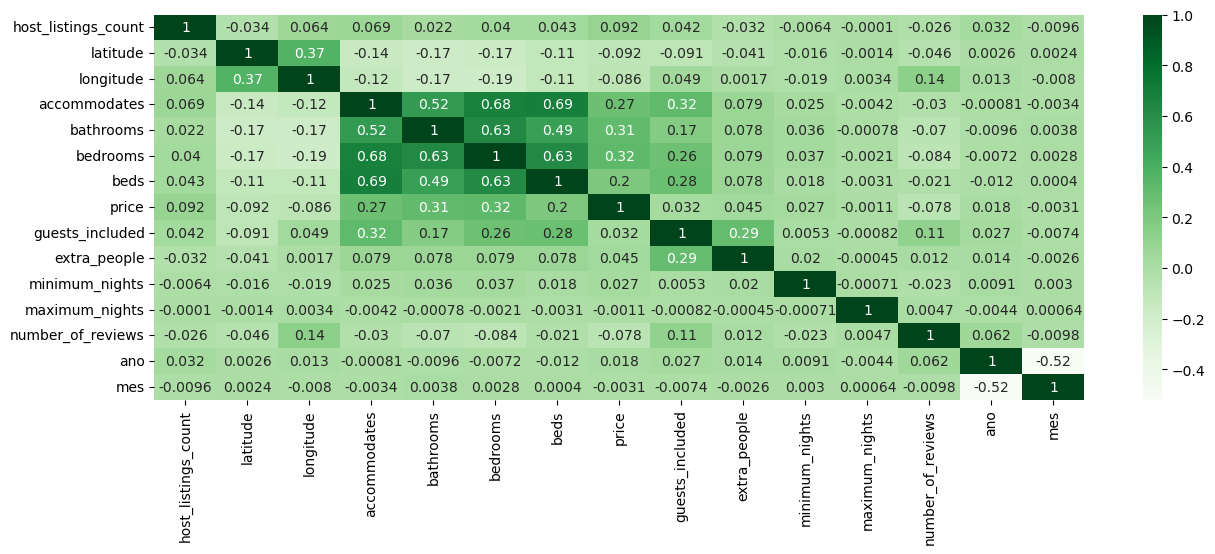

In [17]:
# Forma correta para evitar o erro de conversão
correlacao = base_airbnb.corr(numeric_only=True)


plt.figure(figsize=(15,5))
sns.heatmap(correlacao, annot =True, cmap="Greens")

In [22]:
def limites(coluna):
    q1 = coluna.quantile(0.25)
    q3 = coluna.quantile(0.75)
    amplitude = q3 - q1

    return q1 -1.5 * amplitude, q3 +1.5* amplitude

In [29]:
def diagrama_caixa(coluna):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(15,5)
    sns.boxplot(x=coluna, ax =ax1)
    ax2.set_xlim(limites(coluna))
    sns.boxplot(x=coluna, ax=ax2)

def histograma(coluna):
    plt.figure(figsize=(15, 5))
    # kde=True adiciona a linha da estimativa de densidade (antigo distplot)
    sns.histplot(coluna, kde=True, stat="density", color='royalblue')
    plt.title(f'Distribuição de {coluna.name}')
    plt.xlabel('Valor')
    plt.ylabel('Densidade')
    plt.show()
    

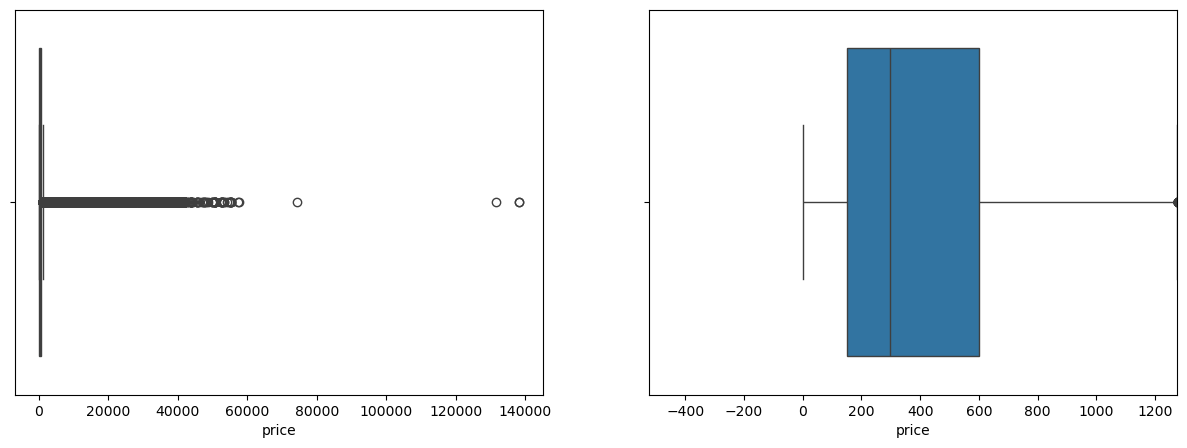

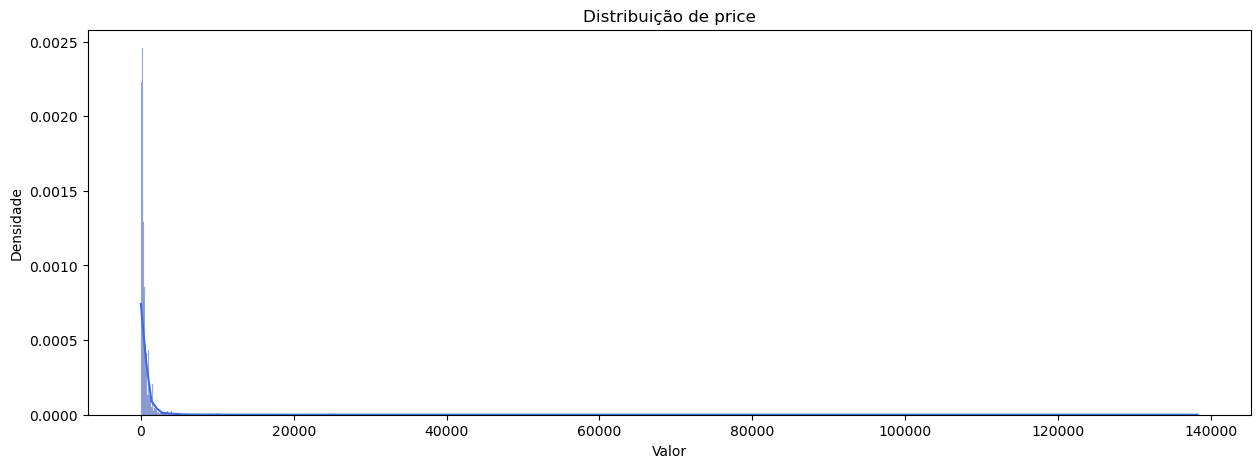

In [30]:
diagrama_caixa(base_airbnb['price'])
histograma(base_airbnb['price'])